In [32]:
# 0
import numpy as np
import pandas as pd

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
        self.betas          = beta_matrix
        self.comp_designs   = competitor_designs
        self.market_size    = market_size

        # Pre-calculate competitor utilities — shape: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas):
        """
        Evaluates a single product.

        our_design  : 2D array (1, total_levels) — one-hot encoded
        our_price   : float
        our_cost    : float — computed from level costs
        price_betas : 2D array (num_respondents, 1)
        """
        feature_utility = np.dot(self.betas, our_design.T)           # (R, 1)
        our_utility     = feature_utility + price_betas * our_price   # (R, 1)
        all_utilities   = np.hstack((self.comp_utilities, our_utility))
        exp_utilities   = np.exp(all_utilities)
        probabilities   = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        market_share    = np.mean(probabilities[:, -1])
        profit          = market_share * self.market_size * (our_price - our_cost)
        return market_share, profit

    def evaluate_portfolio(self, designs_matrix, prices_array, costs_array, price_betas):
        """
        Evaluates all portfolio products simultaneously in one vectorized pass.
        Correctly accounts for cannibalization between portfolio products.

        designs_matrix : 2D array (num_products, total_levels) — one-hot encoded
        prices_array   : 1D array (num_products,)
        costs_array    : 1D array (num_products,)
        price_betas    : 2D array (num_respondents, 1)

        Returns: individual shares (N,), portfolio share (float), portfolio profit (float)
        """
        # Feature utilities: (R, N)
        feature_utils = np.dot(self.betas, designs_matrix.T)

        # Price utilities: (R, N) — each respondent x each product price
        price_utilities = price_betas * prices_array                  # broadcasts to (R, N)

        our_utilities = feature_utils + price_utilities               # (R, N)

        # Stack competitors + our products: (R, C + N)
        all_utilities = np.hstack((self.comp_utilities, our_utilities))
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)

        # Extract only our products' probabilities: (R, N)
        our_probs = probabilities[:, -designs_matrix.shape[0]:]

        # Individual shares and profits
        shares  = np.mean(our_probs, axis=0)                          # (N,)
        profits = shares * self.market_size * (prices_array - costs_array)

        return shares, np.sum(shares), np.sum(profits)

    def compute_commonality(self, designs_matrix, attributes):
        """
        Computes the Commonality Index for the selected portfolio.
        For each attribute, finds what fraction of products share the most
        popular level choice. Averages across all attributes.

        designs_matrix : 2D array (num_products, total_levels)
        attributes     : list of (name, num_levels) tuples

        Returns: commonality as a float between 0 and 1
        """
        agreement_rates = []
        offset = 0
        for _, num_levels in attributes:
            level_slice   = designs_matrix[:, offset : offset + num_levels]  # (N, L)
            level_choices = np.argmax(level_slice, axis=1)                   # (N,)
            counts        = np.bincount(level_choices, minlength=num_levels)
            agreement_rates.append(counts.max() / len(designs_matrix))
            offset += num_levels
        return np.mean(agreement_rates)

In [34]:
# 1
# Each tuple: (attribute_name, num_levels)
# Must match the column order in the Excel file exactly
attributes = [
    ("A1", 9),
    ("A2", 7),
    ("A3", 4),
    ("A4", 6),
    ("A5", 8),
    ("A6", 8),
    ("A7", 4),
    ("A8", 8),
]

# --- Define Competitors ---
# levels: zero-based index of chosen level per attribute
competitors = [
    {"name": "Competitor A", "price": 199.00, "levels": [2, 3, 1, 2, 4, 0, 1, 3]},
    {"name": "Competitor B", "price": 299.00, "levels": [5, 5, 2, 4, 6, 3, 2, 5]},
    {"name": "Competitor C", "price": 399.00, "levels": [7, 6, 3, 5, 7, 6, 3, 6]},
]

# --- Define Candidate Products ---
# The optimizer will pick the best NUM_PRODUCTS from this list
our_products = [
    {"name": "Product 1", "levels": [1, 1, 0, 1, 2, 1, 0, 2]},
    {"name": "Product 2", "levels": [3, 2, 1, 2, 3, 2, 1, 3]},
    {"name": "Product 3", "levels": [4, 3, 2, 3, 4, 4, 2, 4]},
    {"name": "Product 4", "levels": [6, 4, 1, 4, 5, 5, 1, 5]},
    {"name": "Product 5", "levels": [8, 6, 3, 5, 7, 7, 3, 7]},
    {"name": "Product 6", "levels": [2, 0, 0, 0, 1, 0, 0, 1]},
    {"name": "Product 7", "levels": [5, 5, 2, 3, 6, 3, 2, 6]},
    {"name": "Product 8", "levels": [7, 2, 3, 5, 3, 6, 1, 4]},
]

# --- Portfolio Size ---
NUM_PRODUCTS = int(input("Enter the number of products in the final portfolio: "))

# ── Derived quantities — DO NOT TOUCH ─────────────────────────────────────
num_levels    = [a[1] for a in attributes]
total_levels  = sum(num_levels)
start_indices = [sum(num_levels[:i]) for i in range(len(num_levels))]

# --- Validation ---
for prod in our_products:
    assert len(prod["levels"]) == len(attributes), \
        f"{prod['name']} has {len(prod['levels'])} level values but there are {len(attributes)} attributes"
for comp in competitors:
    assert len(comp["levels"]) == len(attributes), \
        f"{comp['name']} has {len(comp['levels'])} level values but there are {len(attributes)} attributes"
print("Validation passed — all products and competitors have the correct number of levels")

# --- Build Competitor Matrix ---
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1
comp_prices = np.array([[c["price"]] for c in competitors])

# --- Build Candidate Matrix ---
candidate_designs = np.zeros((len(our_products), total_levels), dtype=int)
for row, prod in enumerate(our_products):
    for attr_i, level_choice in enumerate(prod["levels"]):
        candidate_designs[row, start_indices[attr_i] + level_choice] = 1

print(f"Attributes     : {[a[0] for a in attributes]}")
print(f"Levels per attr: {num_levels}")
print(f"Competitors    : {len(competitors)}")
print(f"Candidates     : {len(our_products)}  ->  picking best {NUM_PRODUCTS}")

# Load from Excel
file_path = r"E:\NCSU Spring '26\Python\beta_utilities.xlsx"

# --- Beta Values ---
beta_df = pd.read_excel(file_path, sheet_name="Beta Values")
beta_df = beta_df.drop(columns=["Respondent", "NONE"])

assert beta_df.shape[1] == total_levels, (
    f"Mismatch! Code expects {total_levels} columns but file has {beta_df.shape[1]}. "
    f"Check that your attributes list matches the Excel structure."
)

beta_matrix     = beta_df.values
num_respondents = beta_matrix.shape[0]
print(f"\nLoaded {num_respondents} respondents from Beta Values sheet.")

# --- Level Costs ---
cost_df   = pd.read_excel(file_path, sheet_name="Level Costs", index_col=1)
base_cost = cost_df["Base Cost"].iloc[0]
cost_df   = cost_df.drop(columns=["Base Cost"])
print(f"Base cost loaded: ${base_cost:.2f}")

def get_product_cost(levels):
    """
    Computes total cost for a product from its chosen levels.
    Total cost = base cost + sum of level costs across all attributes.
    """
    total = base_cost
    for attr_i, level_choice in enumerate(levels):
        attr_name = attributes[attr_i][0]
        total += cost_df[attr_name].iloc[level_choice]
    return total

# --- Price Sensitivities (simulated for now) ---
price_betas = np.random.normal(loc=-0.01, scale=0.002, size=(num_respondents, 1))

# --- User Inputs ---
market_size          = 500000
price_min = 99
price_max = 999

# --- Instantiate Simulator ---
simulator = MarketSimulator(beta_matrix, competitor_matrix, market_size)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

print(f"\nMarket size : {market_size:,}")
print(f"Price range : ${price_min:.2f} — ${price_max:.2f}")
print(f"\nSample product costs:")
for prod in our_products:
    cost = get_product_cost(prod["levels"])
    print(f"  {prod['name']}: ${cost:.2f}")

Enter the number of products in the final portfolio:  6


Validation passed — all products and competitors have the correct number of levels
Attributes     : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']
Levels per attr: [9, 7, 4, 6, 8, 8, 4, 8]
Competitors    : 3
Candidates     : 8  ->  picking best 6

Loaded 205 respondents from Beta Values sheet.
Base cost loaded: $45.00

Market size : 500,000
Price range : $99.00 — $999.00

Sample product costs:
  Product 1: $225.00
  Product 2: $345.00
  Product 3: $442.00
  Product 4: $507.00
  Product 5: $640.00
  Product 6: $100.00
  Product 7: $575.00
  Product 8: $415.00


In [35]:
# 2 — Portfolio Optimizer

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

class PortfolioOptimizer(ElementwiseProblem):

    def __init__(self, sim, price_betas, candidate_designs, our_products,
                 num_products, price_min, price_max, attributes):

        self.sim               = sim
        self.price_betas       = price_betas
        self.candidate_designs = candidate_designs
        self.our_products      = our_products
        self.num_products      = num_products
        self.num_candidates    = len(our_products)
        self.attributes        = attributes

        # Variables layout: [cand_0, price_0, cand_1, price_1, ...]
        lower_one = np.array([0,                        price_min])
        upper_one = np.array([self.num_candidates - 1,  price_max])
        xl = np.tile(lower_one, num_products)
        xu = np.tile(upper_one, num_products)

        # 3 objectives: portfolio share, portfolio profit, commonality
        super().__init__(n_var=num_products * 2, n_obj=3, xl=xl, xu=xu)

    def _evaluate(self, x, out, *args, **kwargs):

        # --- Decode candidate indices and prices ---
        candidate_indices = [
            int(np.clip(round(x[i * 2]), 0, self.num_candidates - 1))
            for i in range(self.num_products)
        ]
        prices = [x[i * 2 + 1] for i in range(self.num_products)]

        # --- Duplicate guard ---
        if len(set(candidate_indices)) < self.num_products:
            out["F"] = [0, 0, 0]
            return

        # --- Build designs, prices, and costs arrays ---
        designs_matrix = np.array([
            self.candidate_designs[idx] for idx in candidate_indices
        ])
        prices_array = np.array(prices)
        costs_array  = np.array([
            get_product_cost(self.our_products[idx]["levels"])
            for idx in candidate_indices
        ])

        # --- Negative margin guard ---
        if np.any(prices_array < costs_array):
            out["F"] = [0, 0, 0]
            return

        # --- Evaluate portfolio ---
        _, portfolio_share, portfolio_profit = self.sim.evaluate_portfolio(
            designs_matrix, prices_array, costs_array, self.price_betas
        )

        # --- Commonality Index ---
        commonality = self.sim.compute_commonality(designs_matrix, self.attributes)

        # Negate all three — pymoo minimizes, we want to maximize
        out["F"] = [-portfolio_share, -portfolio_profit, -commonality]

In [36]:
#3 Run Optimizer + Print Results

print(f"NUM_PRODUCTS    : {NUM_PRODUCTS}")
print(f"n_candidates    : {n_candidates}")
print(f"n_var           : {n_var}")
print(f"price_min       : {price_min}")
print(f"price_max       : {price_max}")

POP_SIZE = 100
N_GEN    = 500

# --- Run ---
problem = PortfolioOptimizer(
    sim               = simulator,
    price_betas       = price_betas,
    candidate_designs = candidate_designs,
    our_products      = our_products,
    num_products      = NUM_PRODUCTS,
    price_min         = price_min,
    price_max         = price_max,
    attributes        = attributes
)

res = minimize(
    problem,
    NSGA2(pop_size=POP_SIZE),
    ('n_gen', N_GEN),
    verbose=False
)

# --- Extract results ---
portfolio_shares      = -res.F[:, 0] * 100
portfolio_profits     = -res.F[:, 1]
portfolio_commonality = -res.F[:, 2] * 100

# --- Helper: decode one solution into a readable portfolio ---
def decode_solution(x_sol):
    portfolio = []
    for i in range(NUM_PRODUCTS):
        idx   = int(np.clip(round(x_sol[i * 2]), 0, len(our_products) - 1))
        price = x_sol[i * 2 + 1]
        cost  = get_product_cost(our_products[idx]["levels"])
        portfolio.append({
            "name"  : our_products[idx]["name"],
            "levels": our_products[idx]["levels"],
            "price" : price,
            "cost"  : cost
        })
    return portfolio

# --- Helper: print one solution ---
def print_solution(label, x_sol, share, profit, commonality):
    print(f"\n{'=' * 62}")
    print(f"  {label}")
    print(f"  Portfolio share: {share:.2f}%  |  "
          f"Profit: ${profit:,.2f}  |  "
          f"Commonality: {commonality:.2f}%")
    print(f"  {'-' * 57}")
    print(f"  {'Slot':<6} {'Product':<12} {'Levels':<30} {'Price':>8}  {'Cost':>8}")
    print(f"  {'-' * 57}")
    for i, p in enumerate(decode_solution(x_sol)):
        print(f"  P{i+1:<5} {p['name']:<12} {str(p['levels']):<30} "
              f"${p['price']:>7.2f}  ${p['cost']:>7.2f}")

# --- Pareto Summary Table ---
print(f"\nFound {len(res.F)} Pareto-optimal portfolios")
print("=" * 62)
print(f"  {'Portfolio Share':>16}  {'Portfolio Profit':>18}  {'Commonality':>13}")
print("-" * 62)
for share, profit, commonality in zip(portfolio_shares, portfolio_profits, portfolio_commonality):
    print(f"  {share:>15.2f}%  ${profit:>17,.2f}  {commonality:>12.2f}%")

# --- Three Extreme Solutions ---
best_share_idx       = np.argmax(portfolio_shares)
best_profit_idx      = np.argmax(portfolio_profits)
best_commonality_idx = np.argmax(portfolio_commonality)

print_solution("MAX PORTFOLIO SHARE",
               res.X[best_share_idx],
               portfolio_shares[best_share_idx],
               portfolio_profits[best_share_idx],
               portfolio_commonality[best_share_idx])

print_solution("MAX PORTFOLIO PROFIT",
               res.X[best_profit_idx],
               portfolio_shares[best_profit_idx],
               portfolio_profits[best_profit_idx],
               portfolio_commonality[best_profit_idx])

print_solution("MAX COMMONALITY",
               res.X[best_commonality_idx],
               portfolio_shares[best_commonality_idx],
               portfolio_profits[best_commonality_idx],
               portfolio_commonality[best_commonality_idx])

NUM_PRODUCTS    : 6
n_candidates    : 8
n_var           : 12
price_min       : 99
price_max       : 999
xl              : [ 0 99  0 99  0 99  0 99  0 99  0 99]
xu              : [  7 999   7 999   7 999   7 999   7 999   7 999]
xl shape        : (12,)
xu shape        : (12,)

Found 100 Pareto-optimal portfolios
   Portfolio Share    Portfolio Profit    Commonality
--------------------------------------------------------------
            30.77%  $    81,198,561.67         31.25%
            56.22%  $    54,280,365.45         22.92%
            30.86%  $    81,955,174.05         22.92%
            66.42%  $        18,845.80         31.25%
            66.42%  $        18,845.80         31.25%
            36.22%  $    80,182,257.76         29.17%
            37.28%  $    79,526,431.78         29.17%
            54.73%  $    56,152,609.87         31.25%
            32.43%  $    81,620,601.12         22.92%
            62.19%  $    28,995,843.74         31.25%
            49.95%  $    65,02

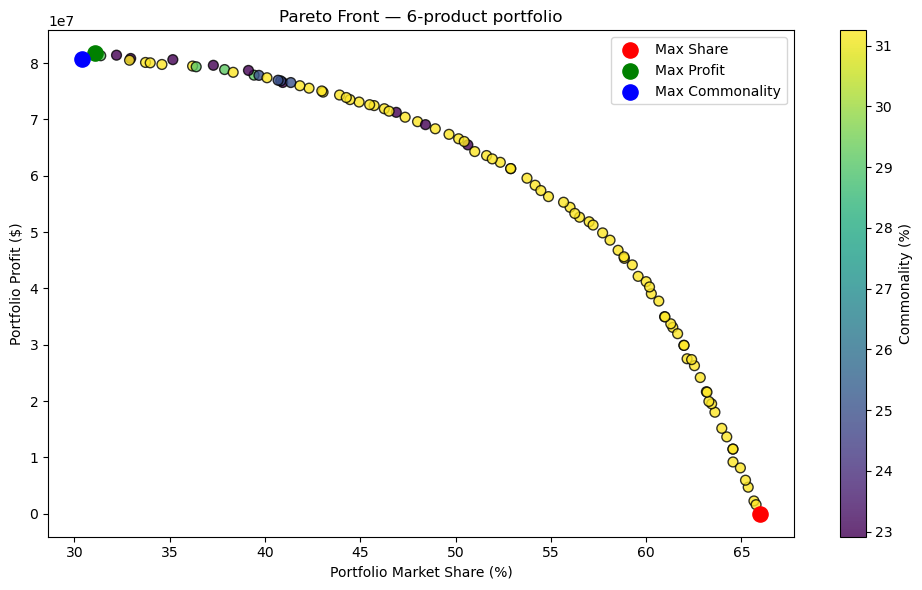

In [31]:
#4 Pareto Front Plot 

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# --- Main scatter — commonality drives the color axis ---
sc = ax.scatter(
    portfolio_shares,
    portfolio_profits,
    c           = portfolio_commonality,
    cmap        = 'viridis',
    s           = 50,
    alpha       = 0.8,
    edgecolors  = 'black'
)
plt.colorbar(sc, ax=ax, label="Commonality (%)")

# --- Mark the three extreme solutions ---
ax.scatter(
    portfolio_shares[best_share_idx],
    portfolio_profits[best_share_idx],
    color='red', s=120, zorder=5, label='Max Share'
)
ax.scatter(
    portfolio_shares[best_profit_idx],
    portfolio_profits[best_profit_idx],
    color='green', s=120, zorder=5, label='Max Profit'
)
ax.scatter(
    portfolio_shares[best_commonality_idx],
    portfolio_profits[best_commonality_idx],
    color='blue', s=120, zorder=5, label='Max Commonality'
)

# --- Labels ---
ax.set_xlabel("Portfolio Market Share (%)")
ax.set_ylabel("Portfolio Profit ($)")
ax.set_title(f"Pareto Front — {NUM_PRODUCTS}-product portfolio")
ax.legend()

plt.tight_layout()
plt.show()